<a href="https://colab.research.google.com/github/LiuCanDoeverything/assignment1ADL/blob/main/Copy_of_2026_EE5438_Assign01__MLP_Fashion_MNIST_Clothing_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [EE5438 Applied Deep Learning](https://eelmpo.github.io/ee5438/index.html)

# 2026 Semester A: EE5438 Assignment 1 (Programming Section B)

## Fashion Item Recognition with Multi-Layer Perceptrons (MLPs)

### Assignment Overview
In this assignment, you are required to implement a Multi-Layer Perceptron (MLP) model for image classification on the Fashion-MNIST dataset. Your goal is to enhance model performance by systematically exploring different feedforward neural network architectures, activation functions, optimization algorithms, regularization techniques, and data augmentation strategies.

A 3-layer MLP model has been implemented in the provided Colab notebook using sigmoid activations, and it is trained without advanced techniques such as batch normalization, dropout, or modern activation functions. Additionally, the model is trained with basic SGD instead of advanced optimizers like Adam.

### Your Task
Starting from the provided notebook, you are expected to **modify the architecture** and **apply advanced training techniques**, including but not limited to:

- **Better optimizers** (e.g., Adam, RMSprop, SGD with momentum)

- **Learning rate schedulers** (e.g., StepLR, CosineAnnealing, ReduceLROnPlateau)

- **Regularization techniques** (e.g., Dropout, Weight Decay, Batch Normalization)

- **Modern activation functions** (e.g., ReLU, Leaky ReLU, GELU, Swish)

- **Data augmentation** (e.g., random flips, rotations, crops, noise injection)

In addition, students are required to write **a short technical summary report** that includes:

1. **Network architecture design** — including a **diagram of the network architecture**

2. **Training strategy** — optimizers, learning rate schedules, regularization, and data augmentation used

3. **Performance analysis** — experimental results, comparisons, and discussion

4. **Conclusion** — key findings and takeaways

###

### Constraints
❌ Convolutional Neural Networks (CNNs) are NOT allowed.

❌ Transformer architectures are NOT allowed.

✅ MLP Mixed architectures ARE allowed (e.g., mixing different layer types within an MLP framework).

### Reproducibility Requirement
Please use your `student number as the random seed` for all experiments so that your experimental results can be replicated.

# Assignment 1: Summary Report

Student Name:
Student Number:

Write your short technical report here:

---
## 1. Setup


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42 # Change this seed number to your student number
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Running on:", device)

PyTorch version: 2.11.0+cu128
Running on: cuda


---
## 2. Load the Fashion-MNIST dataset

**Dataset:** Fashion-MNIST — 70,000 grayscale images of clothing items (28×28 pixels)

Fashion-MNIST was published by Zalando Research as a drop-in replacement for MNIST: same image size, same number of images, same 10-class layout — but instead of handwritten digits the classes are clothing items.

| Label | Class | Label | Class |
|---|---|---|---|
| 0 | T-shirt/top | 5 | Sandal |
| 1 | Trouser | 6 | Shirt |
| 2 | Pullover | 7 | Sneaker |
| 3 | Dress | 8 | Bag |
| 4 | Coat | 9 | Ankle boot |

> **Tip:** `Runtime → Change runtime type → GPU` makes training a few times faster, but this
> notebook trains in about a minute on CPU too.






Same split as MNIST — 60,000 training images and 10,000 test images — and the same two
transforms. The normalisation constants differ because clothing images are brighter on average
than handwritten digits: Fashion-MNIST has mean `0.2860` and std `0.3530`.


In [ ]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),   # Fashion-MNIST mean and std
])

train_set = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=transform)
test_set  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=1000,       shuffle=False)

print(f"Training images: {len(train_set):,}")
print(f"Test images:     {len(test_set):,}")
print(f"Total:           {len(train_set) + len(test_set):,}\n")

counts = np.bincount(train_set.targets.numpy(), minlength=10)
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}  {name:<12} {counts[i]:,} training images")

image, label = train_set[0]
print(f"\nOne sample -> tensor shape {tuple(image.shape)}, label = {label} ({CLASS_NAMES[label]})")
print(f"Flattened, that is {image.numel()} input values per image (28 x 28 = 784)")

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 150kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.9MB/s]

Training images: 60,000
Test images:     10,000
Total:           70,000

  0  T-shirt/top  6,000 training images
  1  Trouser      6,000 training images
  2  Pullover     6,000 training images
  3  Dress        6,000 training images
  4  Coat         6,000 training images
  5  Sandal       6,000 training images
  6  Shirt        6,000 training images
  7  Sneaker      6,000 training images
  8  Bag          6,000 training images
  9  Ankle boot   6,000 training images

One sample -> tensor shape (1, 28, 28), label = 9 (Ankle boot)
Flattened, that is 784 input values per image (28 x 28 = 784)


### A look at the data

Ten examples of each class. Notice how similar **T-shirt/top**, **Pullover**, **Coat** and
**Shirt** look at this resolution — that overlap is where most of the model's errors will come
from.


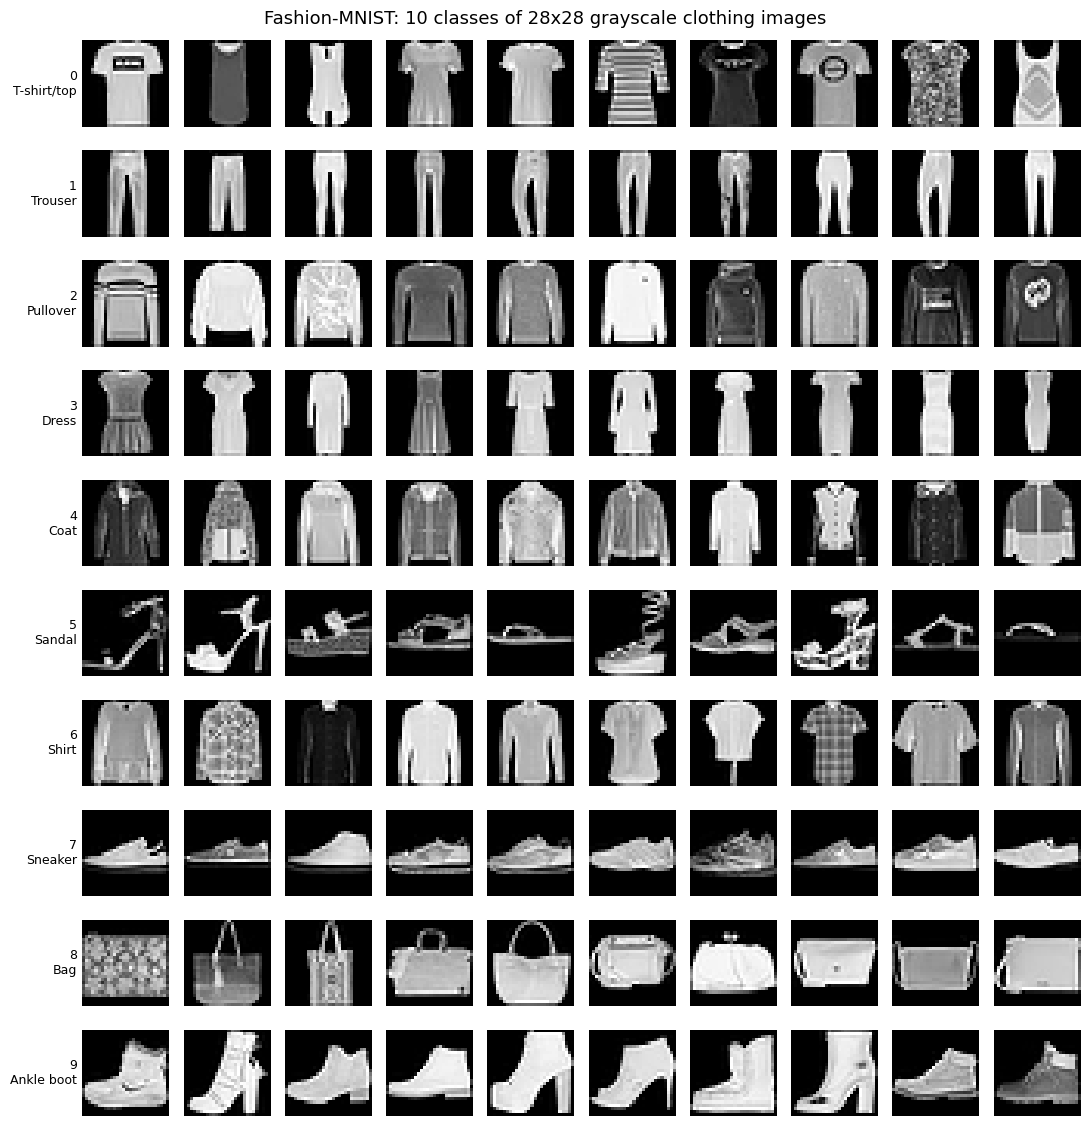

In [ ]:
fig, axes = plt.subplots(10, 10, figsize=(11, 11.5))
targets = train_set.targets.numpy()

for cls in range(10):
    idx = np.where(targets == cls)[0][:10]
    for col, i in enumerate(idx):
        ax = axes[cls, col]
        ax.imshow(train_set.data[i], cmap="gray")
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
    axes[cls, 0].set_ylabel(f"{cls}\n{CLASS_NAMES[cls]}", rotation=0, ha="right",
                            va="center", fontsize=9)

fig.suptitle("Fashion-MNIST: 10 classes of 28x28 grayscale clothing images", fontsize=13)
plt.tight_layout()
plt.show()

### From image to input vector

Just as with the digits, the MLP sees no 2-D grid — the 28×28 image is unrolled into a single
row of 784 values, `pixel 1 … pixel 784`.


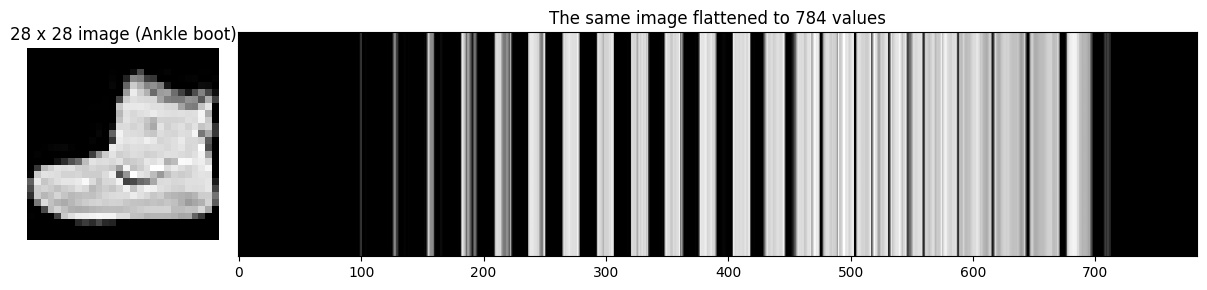

In [ ]:
img, lbl = train_set[0]
flat = img.view(-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3),
                               gridspec_kw={"width_ratios": [1, 5]})
ax1.imshow(img.squeeze(), cmap="gray")
ax1.set_title(f"28 x 28 image ({CLASS_NAMES[lbl]})")
ax1.axis("off")

ax2.imshow(flat.unsqueeze(0), cmap="gray", aspect="auto")
ax2.set_title("The same image flattened to 784 values")
ax2.set_yticks([])
plt.tight_layout()
plt.show()

---
## 3. Build the 3-layer MLP

**Model:** Multi-Layer Perceptron, `784 → 128 → 64 → 10`

![MLP architecture](https://eelmpo.github.io/ee5438/images/mlp-fmnist.png)

```
input  784   (28 x 28 pixels, flattened)
  |  Linear + Sigmoid
hidden 128
  |  Linear + Sigmoid
hidden  64
  |  Linear
output  10   ->  P0 ... P9, one probability per clothing class
```

Exactly the same network as the MNIST notebook — nothing about the architecture is digit-specific, only the meaning of the 10 output units changes.

**Sigmoid** (`1/(1-exp(z))`) sits between the layers; without a non-linearity, stacked linear layers collapse into one linear layer. The final layer emits raw scores (**logits**) — no softmax, because `nn.CrossEntropyLoss` applies it internally in a numerically stable way.


In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()          # (B, 1, 28, 28) -> (B, 784)
        self.fc1 = nn.Linear(784, 128)       # layer 1
        self.fc2 = nn.Linear(128, 64)        # layer 2
        self.fc3 = nn.Linear(64, 10)         # output layer

    def forward(self, x):
        x = self.flatten(x)
        x = F.sigmoid(self.fc1(x))
        x = F.sigmoid(self.fc2(x))
        return self.fc3(x)                   # logits, no softmax here


model = MLP().to(device)
print(model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


### Counting the 109,386 parameters

```
weights: 784*128 + 128*64 + 64*10 = 100,352 + 8,192 + 640 = 109,184
biases:      128 +      64 +    10 =                            202
total:                                                       109,386
```


In [ ]:
total = 0
print(f"{'Layer':<10}{'Weights':>12}{'Biases':>10}{'Subtotal':>12}")
print("-" * 44)
for name, layer in [("fc1", model.fc1), ("fc2", model.fc2), ("fc3", model.fc3)]:
    w = layer.weight.numel()
    b = layer.bias.numel()
    total += w + b
    print(f"{name:<10}{w:>12,}{b:>10,}{w + b:>12,}")
print("-" * 44)
print(f"{'TOTAL':<10}{'':>12}{'':>10}{total:>12,}")

assert total == 109_386
print(f"\n{total/1000:.3f}K trainable parameters")

Layer          Weights    Biases    Subtotal
--------------------------------------------
fc1            100,352       128     100,480
fc2              8,192        64       8,256
fc3                640        10         650
--------------------------------------------
TOTAL                                109,386

109.386K trainable parameters


---
## 4. Loss function and optimizer

* **Loss — `CrossEntropyLoss`:** standard for single-label classification.
* **Optimizer — `Adam` with learning rate `1e-3`.**

One difference from the MNIST run: Fashion-MNIST overfits noticeably sooner, so we keep every
epoch's test accuracy and restore the best-performing weights at the end instead of simply
taking the last epoch.


In [ ]:
EPOCHS = 50
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)


def train_one_epoch(model, loader):
    model.train()
    running_loss, correct, seen = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # 1. clear old gradients
        logits = model(images)         # 2. forward pass
        loss = criterion(logits, labels)
        loss.backward()                # 3. backpropagation
        optimizer.step()               # 4. update the weights

        running_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        seen += labels.size(0)
    return running_loss / seen, correct / seen


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss, correct, seen = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        running_loss += criterion(logits, labels).item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        seen += labels.size(0)
    return running_loss / seen, correct / seen

---
## 5. Train the model


In [ ]:
import copy

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_acc, best_state, best_epoch = 0.0, None, 0

print(f"{'Epoch':>6}{'Train loss':>13}{'Train acc':>12}{'Test loss':>12}{'Test acc':>11}")
print("-" * 54)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    te_loss, te_acc = evaluate(model, test_loader)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    flag = ""
    if te_acc > best_acc:
        best_acc, best_epoch = te_acc, epoch
        best_state = copy.deepcopy(model.state_dict())
        flag = "  <- best"

    print(f"{epoch:>6}{tr_loss:>13.4f}{tr_acc:>11.2%}{te_loss:>12.4f}{te_acc:>10.2%}{flag}")

model.load_state_dict(best_state)
print(f"\nBest test accuracy: {best_acc:.2%} (epoch {best_epoch}) - weights restored")

 Epoch   Train loss   Train acc   Test loss   Test acc
------------------------------------------------------
     1       2.3279     10.00%      2.3091    10.00%  <- best
     2       2.3020     10.00%      2.2971    10.00%
     3       2.2939     12.13%      2.2912    15.28%  <- best
     4       2.2886     27.88%      2.2863    35.09%  <- best
     5       2.2837     40.33%      2.2814    42.13%  <- best
     6       2.2787     44.08%      2.2763    42.91%  <- best
     7       2.2735     46.11%      2.2710    43.93%  <- best
     8       2.2680     47.23%      2.2653    43.99%  <- best
     9       2.2620     44.18%      2.2591    46.51%  <- best
    10       2.2556     47.59%      2.2525    46.43%
    11       2.2487     46.96%      2.2453    46.95%  <- best
    12       2.2411     48.26%      2.2374    46.02%
    13       2.2327     47.98%      2.2286    45.26%
    14       2.2235     47.45%      2.2190    45.08%
    15       2.2133     46.29%      2.2083    45.12%
    16       2

### Training curves

The gap between the two accuracy lines is the interesting part here. On MNIST the curves stay
close together; on Fashion-MNIST the training accuracy keeps climbing past 92% while the test
accuracy stalls near 89% — that widening gap is the model memorising the training set.


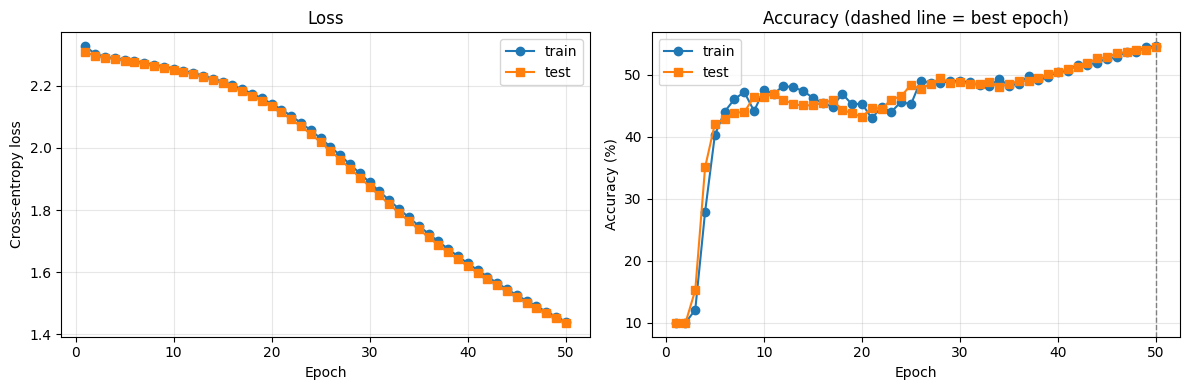

In [ ]:
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_loss"], "o-", label="train")
ax1.plot(epochs, history["test_loss"], "s-", label="test")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-entropy loss")
ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=.3)

ax2.plot(epochs, [a * 100 for a in history["train_acc"]], "o-", label="train")
ax2.plot(epochs, [a * 100 for a in history["test_acc"]], "s-", label="test")
ax2.axvline(best_epoch, color="gray", ls="--", lw=1)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy (dashed line = best epoch)"); ax2.legend(); ax2.grid(alpha=.3)

plt.tight_layout()
plt.show()

---
## 6. Evaluate

### Overall accuracy and per-class scores

Watch the per-class F1 column: trousers, bags and footwear score in the high 90s, while
**Shirt** typically drops to around 0.70 because it competes with T-shirt, pullover and coat.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    preds, trues, probs = [], [], []
    for images, labels in loader:
        logits = model(images.to(device))
        p = F.softmax(logits, dim=1)
        probs.append(p.cpu())
        preds.append(p.argmax(1).cpu())
        trues.append(labels)
    return (torch.cat(preds).numpy(), torch.cat(trues).numpy(), torch.cat(probs).numpy())


y_pred, y_true, y_prob = predict_all(model, test_loader)
accuracy = (y_pred == y_true).mean()

print(f"Test accuracy: {accuracy:.2%}  ({(y_pred == y_true).sum():,} / {len(y_true):,} correct)")
print(f"Errors:        {(y_pred != y_true).sum():,}\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

Test accuracy: 54.54%  (5,454 / 10,000 correct)
Errors:        4,546

              precision    recall  f1-score   support

 T-shirt/top     0.5794    0.5690    0.5742      1000
     Trouser     0.5011    0.9430    0.6544      1000
    Pullover     0.3883    0.5390    0.4514      1000
       Dress     0.2765    0.1330    0.1796      1000
        Coat     0.3763    0.3970    0.3864      1000
      Sandal     0.7372    0.3310    0.4569      1000
       Shirt     0.3622    0.0460    0.0816      1000
     Sneaker     0.5795    0.9290    0.7138      1000
         Bag     0.8230    0.7160    0.7658      1000
  Ankle boot     0.7317    0.8510    0.7869      1000

    accuracy                         0.5454     10000
   macro avg     0.5355    0.5454    0.5051     10000
weighted avg     0.5355    0.5454    0.5051     10000



### Confusion matrix

Row = the true class, column = the prediction. The off-diagonal cells cluster in the top-left
block — the four upper-body garments — while shoes and bags are almost never confused with
clothing.


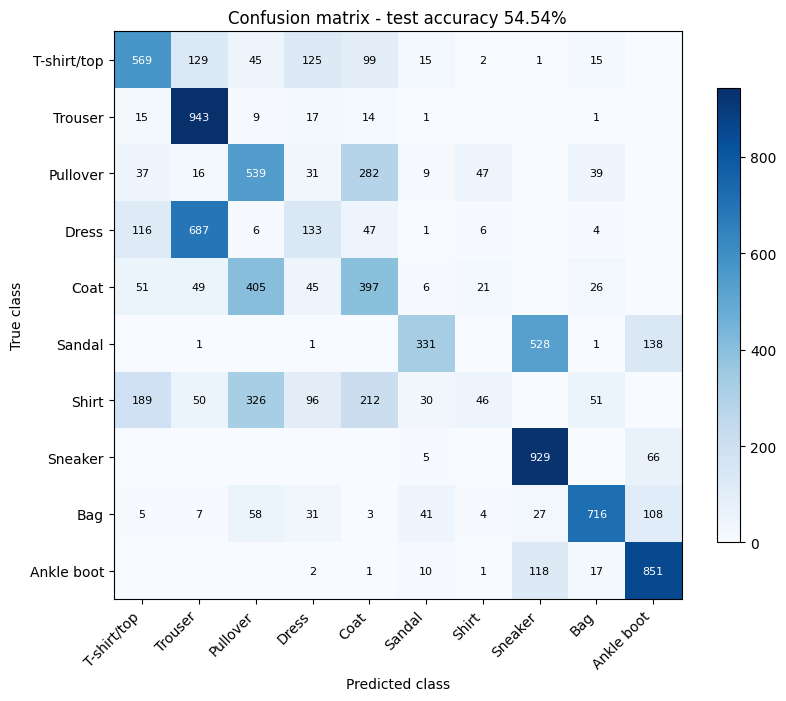

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
ax.set_title(f"Confusion matrix - test accuracy {accuracy:.2%}")

for i in range(10):
    for j in range(10):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.colorbar(im, ax=ax, shrink=.8)
plt.tight_layout()
plt.show()

### The most confused pairs

Ranking the off-diagonal cells makes the failure modes explicit.


In [ ]:
pairs = [(cm[i, j], i, j) for i in range(10) for j in range(10) if i != j]
pairs.sort(reverse=True)

print("Top 10 confusions:\n")
print(f"{'True class':<14}{'Predicted as':<14}{'Count':>7}{'% of class':>12}")
print("-" * 47)
for count, i, j in pairs[:10]:
    print(f"{CLASS_NAMES[i]:<14}{CLASS_NAMES[j]:<14}{count:>7}{count / cm[i].sum():>11.1%}")

Top 10 confusions:

True class    Predicted as    Count  % of class
-----------------------------------------------
Dress         Trouser           687      68.7%
Sandal        Sneaker           528      52.8%
Coat          Pullover          405      40.5%
Shirt         Pullover          326      32.6%
Pullover      Coat              282      28.2%
Shirt         Coat              212      21.2%
Shirt         T-shirt/top       189      18.9%
Sandal        Ankle boot        138      13.8%
T-shirt/top   Trouser           129      12.9%
T-shirt/top   Dress             125      12.5%


### Where the model gets it wrong


4546 misclassified images. Showing the first 20:


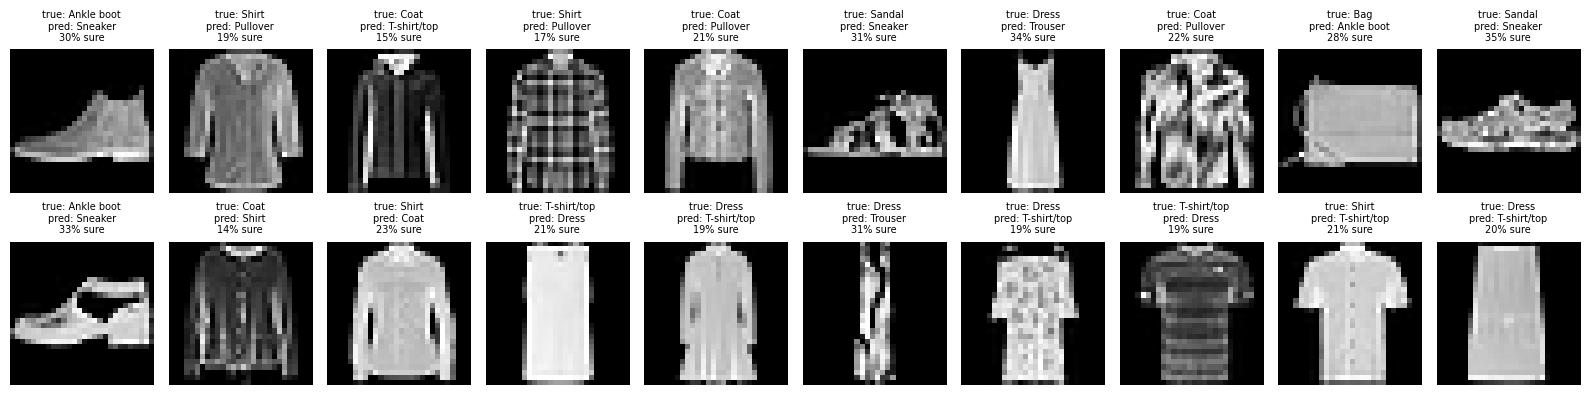

In [ ]:
wrong = np.where(y_pred != y_true)[0]
print(f"{len(wrong)} misclassified images. Showing the first 20:")

fig, axes = plt.subplots(2, 10, figsize=(16, 4.2))
for ax, i in zip(axes.ravel(), wrong[:20]):
    ax.imshow(test_set.data[i], cmap="gray")
    ax.set_title(f"true: {CLASS_NAMES[y_true[i]]}\npred: {CLASS_NAMES[y_pred[i]]}"
                 f"\n{y_prob[i].max():.0%} sure", fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## 7. Predict a single item

One image in, ten probabilities `P0 … P9` out, and the largest one is the answer.


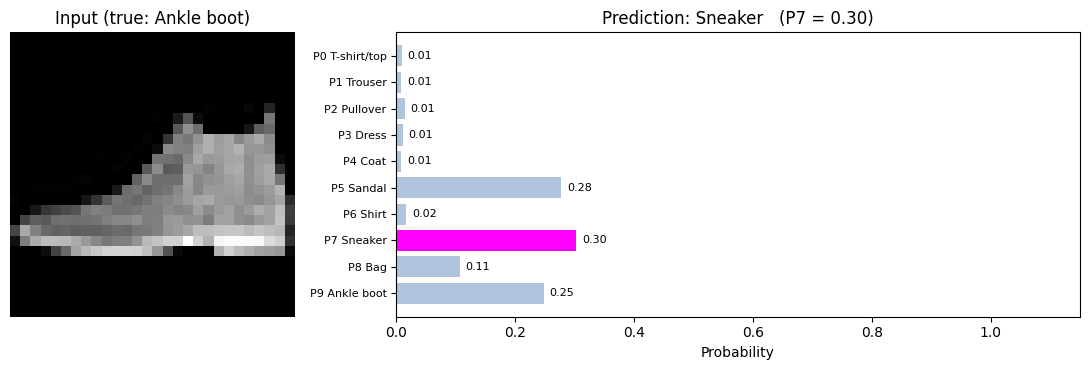

In [ ]:
def show_prediction(index):
    image, true_label = test_set[index]
    with torch.no_grad():
        probs = F.softmax(model(image.unsqueeze(0).to(device)), dim=1)[0].cpu().numpy()
    pred = probs.argmax()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8),
                                   gridspec_kw={"width_ratios": [1, 2.4]})
    ax1.imshow(image.squeeze(), cmap="gray")
    ax1.set_title(f"Input (true: {CLASS_NAMES[true_label]})")
    ax1.axis("off")

    colors = ["magenta" if c == pred else "lightsteelblue" for c in range(10)]
    ax2.barh(range(10), probs, color=colors)
    ax2.set_yticks(range(10))
    ax2.set_yticklabels([f"P{c} {CLASS_NAMES[c]}" for c in range(10)], fontsize=8)
    ax2.invert_yaxis()
    ax2.set_xlim(0, 1.15); ax2.set_xlabel("Probability")
    ax2.set_title(f"Prediction: {CLASS_NAMES[pred]}   (P{pred} = {probs[pred]:.2f})")
    for c, p in enumerate(probs):
        ax2.text(p + .01, c, f"{p:.2f}", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


show_prediction(0)      # try any index from 0 to 9999

---
## 8. Save the model


In [ ]:
torch.save(model.state_dict(), "fashion_mnist_mlp.pt")
print(f"Saved fashion_mnist_mlp.pt ({os.path.getsize('fashion_mnist_mlp.pt') / 1024:.0f} KB)")

# Reload it later like this:
# loaded = MLP().to(device)
# loaded.load_state_dict(torch.load("fashion_mnist_mlp.pt", map_location=device))
# loaded.eval()

# In Colab, to download the file:
# from google.colab import files; files.download("fashion_mnist_mlp.pt")

Saved fashion_mnist_mlp.pt (430 KB)
